L'objet `Dataset` contient les paramètres du problème :
- $T=\{t_1\dots t_n\}$ l'ensemble des Tâches à effectuer.
- $M=\{m_1\dots m_k\}$ l'ensemble des Machines virtuelles disponibles.
- $D_{ij}$ le volume de Données à transférer de $t_i$ à $t_j$. Si $t_i$ n'est pas un prédécesseur de $t_j$, alors $D_{ij}=0$.
- $BW_{rs}$ la bande passante (BandWidth) entre $m_r$ et $m_s$.
- $TRC_{rs}$ le coût de communication (Transfer Cost) entre $m_r$ et $m_s$ par unité de temps.

où chaque tâche est caractérisée par
- $WL_i$ millions d'intructions (WorkLoad) nécéssaires à l'exécution de $t_i$.

et chaque machine par
- $PU_r$ le Prix d'utilisation de $m_r$ par Unité de temps
- $MIPS_r$ capacité de calcul en Millions d'Instructions Par Secondes de $m_r$.

In [1]:
import os
from data.dataset import Dataset

dataset = Dataset(
        workflow_path=os.path.join("data", "CyberShake_100.xml"),
        # workflow_path=os.path.join("data", "Epigenomics_100.xml"),
        # workflow_path=os.path.join("data", "Inspiral_100.xml"),
        # workflow_path=os.path.join("data", "Montage_100.xml"),
        environment_path=os.path.join("data", "task120.xlsx")
)

Data volumes (100, 100)


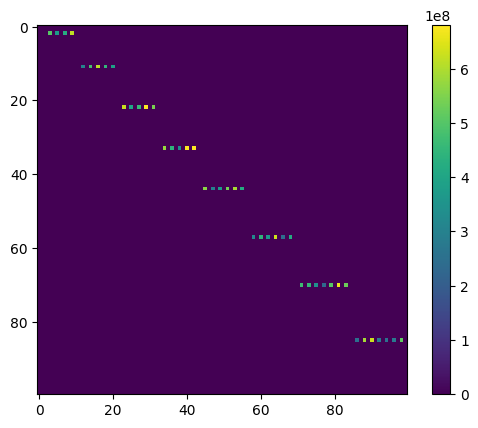

Bandwidth (13, 13)


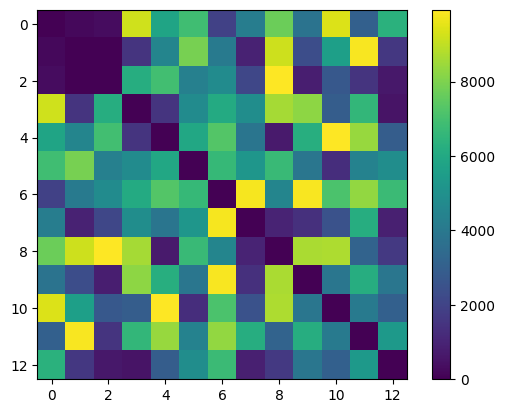

Bandwidth cost (13, 13)


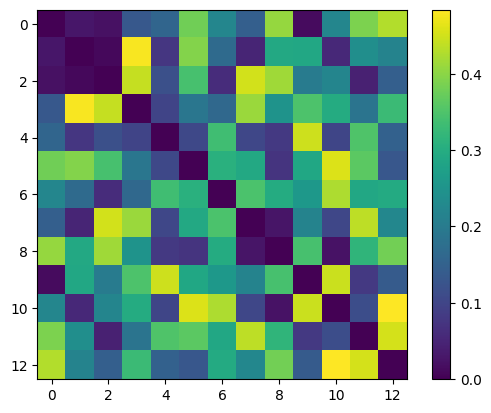

In [2]:
import matplotlib.pyplot as plt

def plot_matrix(mat):
    plt.imshow(mat)
    plt.colorbar()
    plt.show()

print(f"Data volumes {dataset.data_volume.shape}")
plot_matrix(dataset.data_volume)
print(f"Bandwidth {dataset.bandwidth.shape}")
plot_matrix(dataset.bandwidth)
print(f"Bandwidth cost {dataset.bandwidth_cost.shape}")
plot_matrix(dataset.bandwidth_cost)

In [3]:
POPULATION_SIZE = 50
N_GENERATIONS = 100

In [4]:
from nsga import run_nsga2

nsga2_population, nsga2_objectives = run_nsga2(dataset, POPULATION_SIZE, N_GENERATIONS)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |      3 |             - |             -
     2 |      100 |      3 |  0.1108097837 |         ideal
     3 |      150 |      4 |  0.1057571074 |         ideal
     4 |      200 |      5 |  0.0757995593 |             f
     5 |      250 |      5 |  0.0560022692 |             f
     6 |      300 |      5 |  0.0441239239 |             f
     7 |      350 |      6 |  0.0214137466 |             f
     8 |      400 |      1 |  5.766686E+04 |         ideal
     9 |      450 |      1 |  0.000000E+00 |             f
    10 |      500 |      2 |  1.0000000000 |         ideal
    11 |      550 |      2 |  0.000000E+00 |             f
    12 |      600 |      2 |  0.000000E+00 |             f
    13 |      650 |      2 |  0.000000E+00 |             f
    14 |      700 |      2 |  0.000000E+00 |             f
    15 |      750 |      2 |  0.000000E+00 |             f
    16 |      800 |      2 |  0.000000E+00 |            

In [5]:
from maoa import run_moaoa

moaoa_result = run_moaoa(dataset, POPULATION_SIZE, N_GENERATIONS)

Iteration 0,  best cost: 959456.4995567384, best makespan: 485929.10250065924, Archive Size: 3
Iteration 1,  best cost: 855751.6823712918, best makespan: 453660.2273728924, Archive Size: 1
Iteration 2,  best cost: 772359.5015144588, best makespan: 403720.0003822923, Archive Size: 2
Iteration 3,  best cost: 772359.5015144588, best makespan: 403720.0003822923, Archive Size: 2
Iteration 4,  best cost: 772359.5015144588, best makespan: 403720.0003822923, Archive Size: 3
Iteration 5,  best cost: 772359.5015144588, best makespan: 403720.0003822923, Archive Size: 3
Iteration 6,  best cost: 735105.0336744812, best makespan: 389086.9822972846, Archive Size: 5
Iteration 7,  best cost: 735105.0336744812, best makespan: 323731.1893205677, Archive Size: 6
Iteration 8,  best cost: 691606.9881211813, best makespan: 323731.1893205677, Archive Size: 8
Iteration 9,  best cost: 691606.9881211813, best makespan: 323731.1893205677, Archive Size: 8
Iteration 10,  best cost: 691606.9881211813, best makespan:

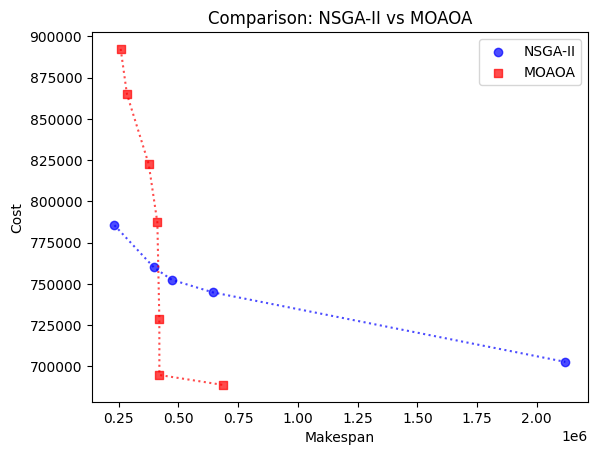

In [12]:
from compar import plot_comparison
    
plot_comparison(nsga2_objectives, moaoa_result)

In [8]:
import numpy as np

def get_best_solutions(archive):
    best_cost_solution = archive[:, -1].argmin()
    best_makespan_solution = archive[:, -2].argmin()
    best_compromise_solution = (archive[:, -1]+archive[:, -2]).argmin()
    return [archive[best_cost_solution], archive[best_makespan_solution], archive[best_compromise_solution]]

# histogram of the number of tasks per machine
def plot_tasks_per_machine(dataset, solution, ax):
    tasks_per_machine = np.sum(solution, axis=0)
    ax.bar(range(dataset.n_machines), tasks_per_machine)
    ax.set_xlabel('Machine')
    ax.set_ylabel('Number of tasks')
    ax.set_title('Tasks per machine')

# histogram of number of tasks ran on cloud and fog
def plot_cloud_fog(dataset, solution, ax):
    cloud_indices = np.where([machine.is_cloud for machine in dataset.machines])
    fog_indices = np.where([not machine.is_cloud for machine in dataset.machines])
    cloud_tasks = np.sum(solution.T[cloud_indices])
    fog_tasks = np.sum(solution.T[fog_indices])
    ax.bar(['Cloud', 'Fog'], [cloud_tasks, fog_tasks])
    ax.set_xlabel('Machine type')
    ax.set_ylabel('Number of tasks')
    ax.set_title('Tasks ran on cloud and fog')

In [9]:
def analyse_results(result):
    solutions = get_best_solutions(result)
    objectives = [solutions[i][-2:] for i in range(len(solutions))]
    for i in range(len(solutions)):
        solutions[i] = solutions[i][:-2].reshape((dataset.n_tasks, dataset.n_machines)).astype(int)

    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Best cost solution\n Makespan = {objectives[0][0]}, Cost = {objectives[0][1]}")
    plot_tasks_per_machine(dataset, solutions[0], axs[0])
    plot_cloud_fog(dataset, solutions[0], axs[1])
    plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Best makespan solution\n Makespan = {objectives[1][0]}, Cost = {objectives[1][1]}")
    plot_tasks_per_machine(dataset, solutions[1], axs[0])
    plot_cloud_fog(dataset, solutions[1], axs[1])
    plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Best compromise solution\n Makespan = {objectives[2][0]}, Cost = {objectives[2][1]}")
    plot_tasks_per_machine(dataset, solutions[2], axs[0])
    plot_cloud_fog(dataset, solutions[2], axs[1])
    plt.show()

In [10]:
# combine nsga2_population and nsga2_objectives to make it the same shape as moaoa_result
nsga2_result = np.concatenate((nsga2_population, nsga2_objectives), axis=1)
nsga2_result.shape

(5, 1302)

NSGA-II


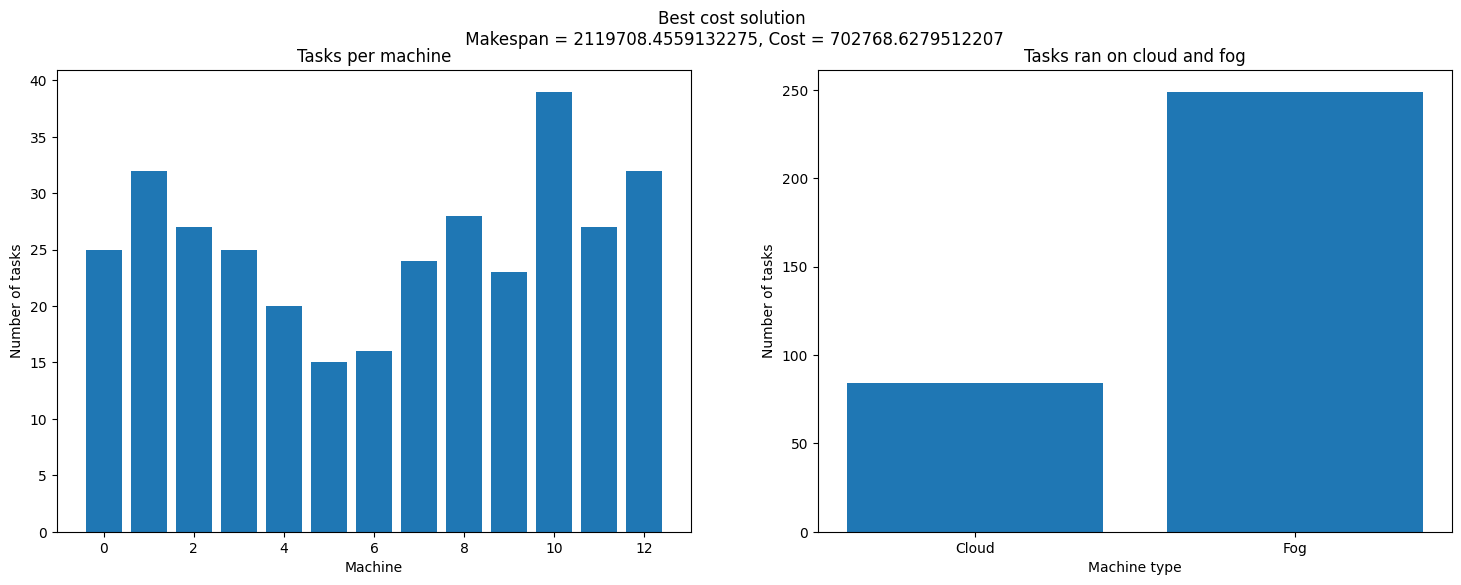

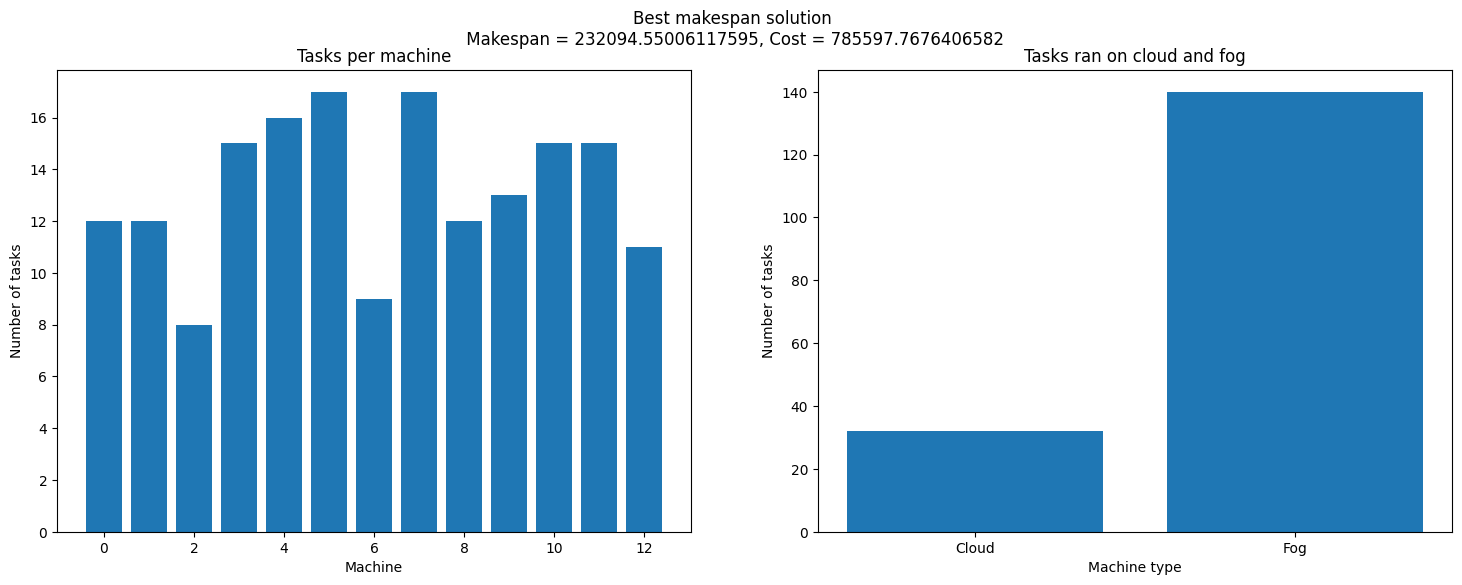

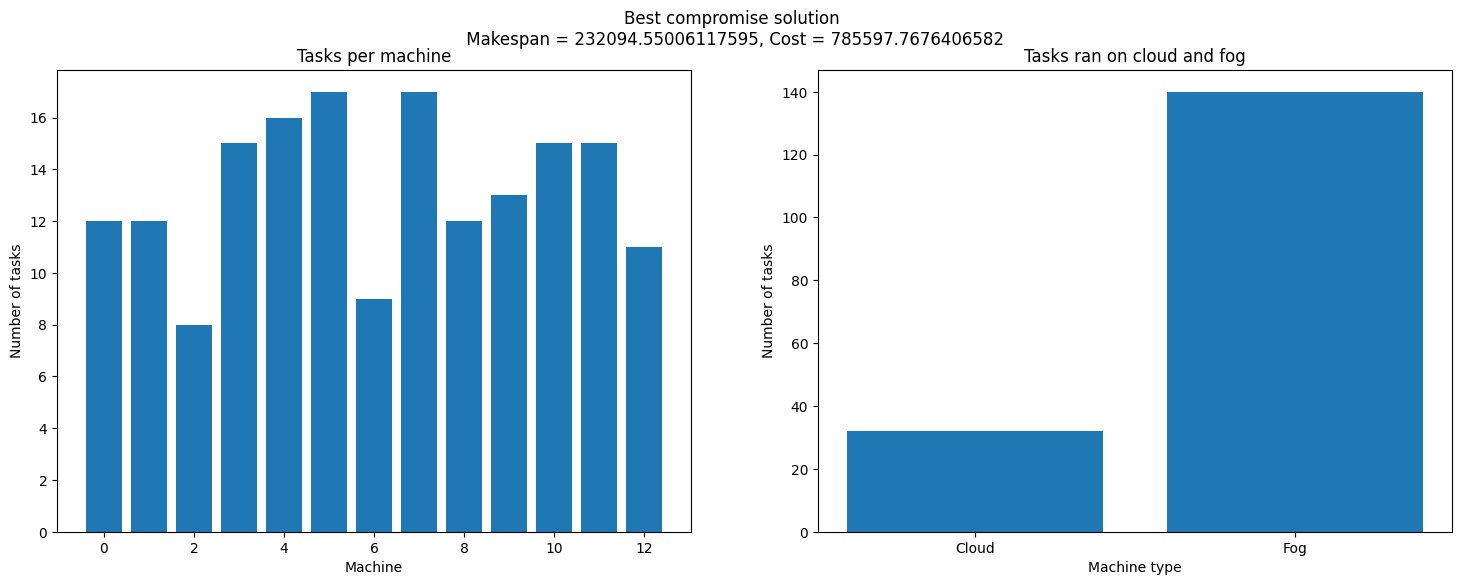

MOAOA


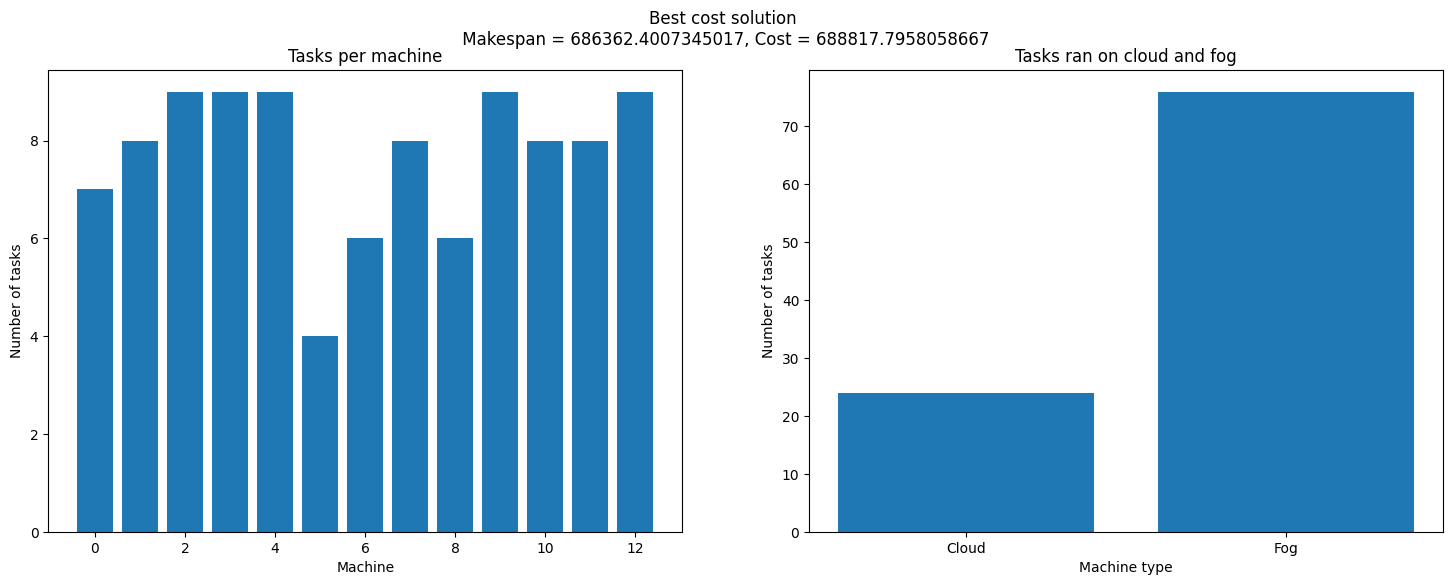

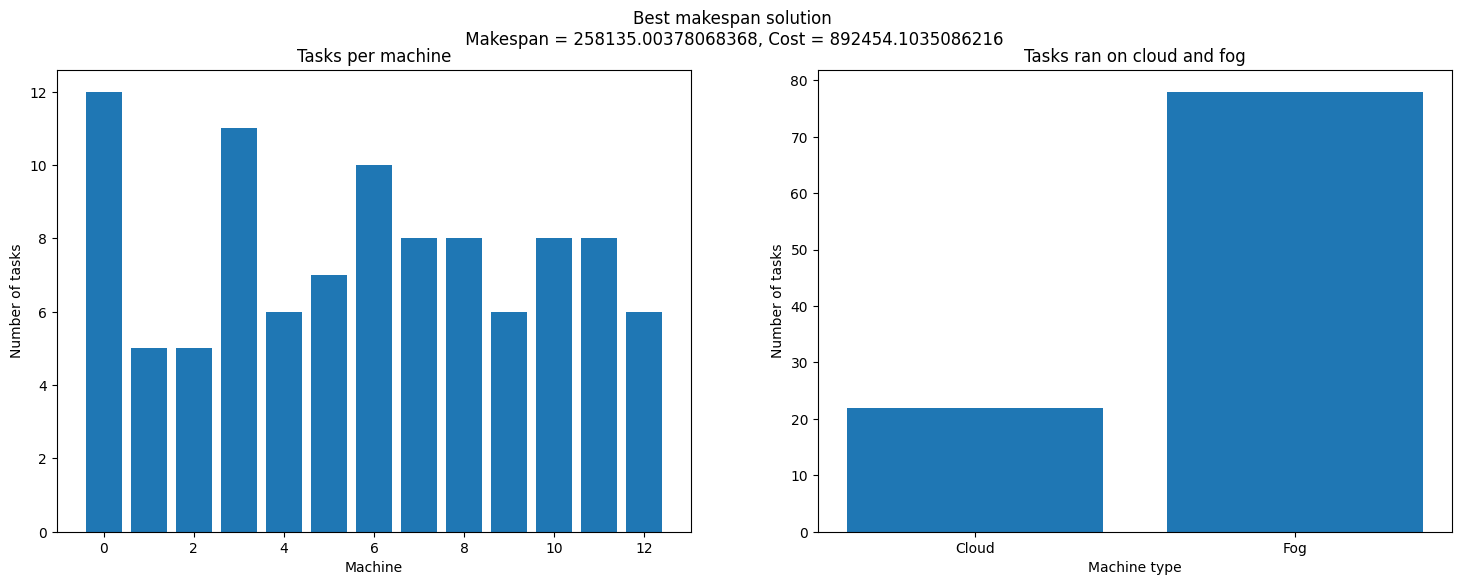

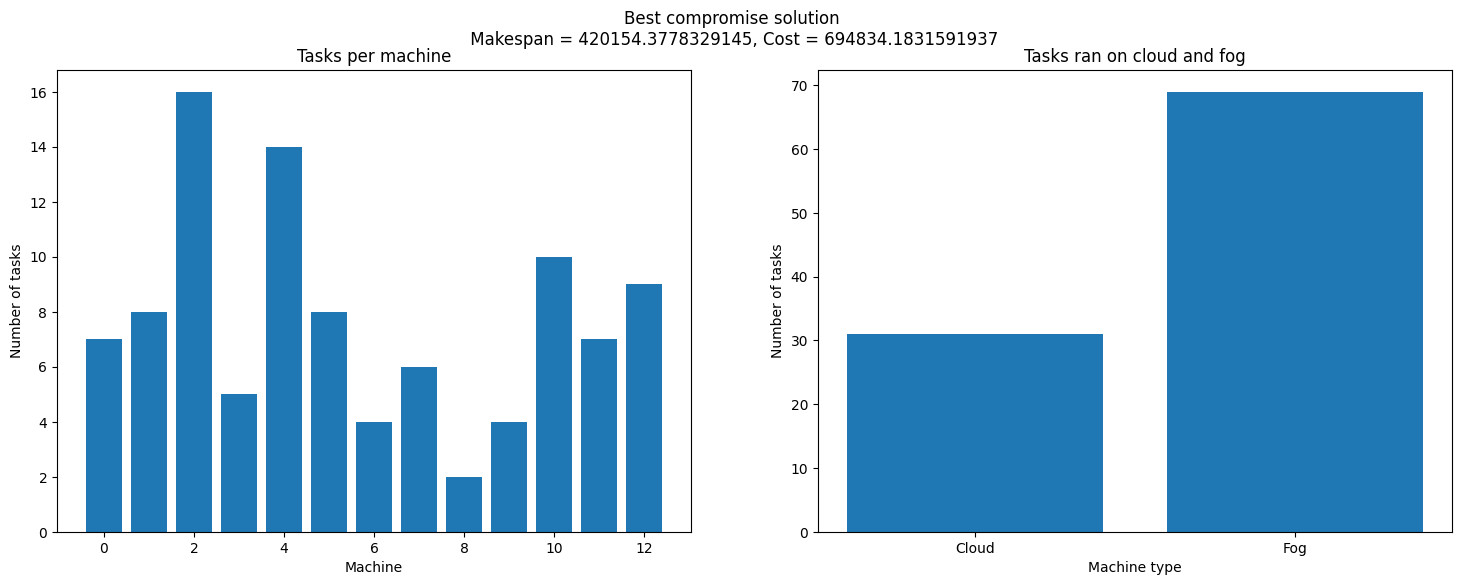

In [11]:
print("NSGA-II")
analyse_results(nsga2_result)
print("MOAOA")
analyse_results(moaoa_result)